# DeFiPy: Python SDK for DeFi Analytics
## Chapter 3: DeFi AMM Math

### Listing 3.1: Uniswap V2 setup

In [95]:
from defipy import ERC20, UniswapFactory, UniswapExchangeData, Join, Swap

# Step 1: Initialize tokens
dai = ERC20("DAI", "0x111")
eth = ERC20("ETH", "0x89")

# Step 2: Initialize UniswapExchangeData
exch_data = UniswapExchangeData(tkn0=eth, tkn1=dai, symbol="LP", address="0x2")

# Step 3: Setup factory
factory = UniswapFactory("ETH pool factory", "0x2")

# Step 4: Deploy pool
lp = factory.deploy(exch_data)

# Step 5: Initialize liquidity pool
join = Join()
join.apply(lp, "user", 100, 100000)

# Pool Summary
lp.summary()

Exchange ETH-DAI (LP)
Reserves: ETH = 100.0, DAI = 100000.0
Liquidity: 3162.2776601683795 



### Listing 3.2: Uniswap V2 manual swap

In [96]:
dy = 1000
gamma = 997 / 1000
x = lp.get_reserve(eth)
y = lp.get_reserve(dai)
dx = (gamma * x * dy) / (y + gamma * dy)
print(f'We receive {dx:.5f} ETH for {dy} DAI')

We receive 0.98716 ETH for 1000 DAI


### Listing 3.3: Uniswap V2 swap

In [97]:
# Step 6: Perform swap
swap = Swap()
out = swap.apply(lp, dai, "user", dy)

# Pool summary
lp.summary()
print(f'We receive {out:.5f} ETH for {dy:.5f} DAI')

Exchange ETH-DAI (LP)
Reserves: ETH = 99.01284196560295, DAI = 101000.0
Liquidity: 3162.2776601683795 

We receive 0.98716 ETH for 1000.00000 DAI


### Listing 3.4: Uniswap V2 manual withdraw

In [98]:
dx = 1
x = lp.get_reserve(eth)
y = lp.get_reserve(dai)
L = lp.get_liquidity()

dL = dx * L / x
dy = y * dL / L
new_x = (x - dx)
new_y = (y - dy)
new_L = L - dL
print(f'The updated reserves are {new_x:.3f} ETH and {new_y:.3f} DAI, and the updated liquidity is {new_L:.3f}')

The updated reserves are 98.013 ETH and 99979.930 DAI, and the updated liquidity is 3130.340


### Listing 3.5: Uniswap V2 double-sided withdraw

In [99]:
from defipy import RemoveLiquidity

# Step 6: Double-sided withdraw
removeliquidity = RemoveLiquidity()
removeliquidity.apply(lp, eth, "user", dx)

# Pool summary
lp.summary()

Exchange ETH-DAI (LP)
Reserves: ETH = 98.01284196560295, DAI = 99979.9303
Liquidity: 3130.339604483977 



### Listing 3.6: Uniswap V2 setup

In [100]:
# Step 1: Initialize tokens
dai = ERC20("DAI", "0x111")
eth = ERC20("ETH", "0x89")

# Step 2: Initialize UniswapExchangeData
exch_data = UniswapExchangeData(tkn0=eth, tkn1=dai, symbol="LP", address="0x2")

# Step 3: Initialize factory
factory = UniswapFactory("ETH pool factory", "0x2")

# Step 4: Deploy pool
lp = factory.deploy(exch_data)

# Step 5: Initialize liquidity pool
join = Join()
join.apply(lp, "user", 100, 100000)

# Pool summary
lp.summary()

Exchange ETH-DAI (LP)
Reserves: ETH = 100.0, DAI = 100000.0
Liquidity: 3162.2776601683795 



### Listing 3.7: Uniswap V2 manual double-sided deposit

In [101]:
dx = 1
x = lp.get_reserve(eth)
y = lp.get_reserve(dai)
L = lp.get_liquidity()

dL = dx * L / x
dy = y * dL / L
new_x = (x + dx)
new_y = (y + dy)
new_L = L + dL

print(f'The updated reserves are {new_x:.3f} ETH and {new_y:.3f} DAI, and the updated liquidity is {new_L:.3f}')

The updated reserves are 101.000 ETH and 101000.000 DAI, and the updated liquidity is 3193.900


### Listing 3.8: Uniswap V2 double-sided deposit

In [102]:
from defipy import AddLiquidity

# Step 6: Double-sided deposit
addliquidity = AddLiquidity()
addliquidity.apply(lp, eth, "user", dx)

# Pool summary
lp.summary()

Exchange ETH-DAI (LP)
Reserves: ETH = 101.0, DAI = 101000.0
Liquidity: 3193.900436770063 



### Listing 3.9: Uniswap V2 setup

In [103]:
# Step 1: Initialize tokens
dai = ERC20("DAI", "0x111")
eth = ERC20("ETH", "0x89")

# Step 2: Initialize UniswapExchangeData
exch_data = UniswapExchangeData(tkn0=eth, tkn1=dai, symbol="LP", address="0x2")

# Step 3: Initialize factory
factory = UniswapFactory("ETH pool factory", "0x2")

# Step 4: Deploy pool
lp = factory.deploy(exch_data)

# Step 5: Initialize liquidity pool
join = Join()
join.apply(lp, "user", 100, 100000)

# Pool summary
lp.summary()

Exchange ETH-DAI (LP)
Reserves: ETH = 100.0, DAI = 100000.0
Liquidity: 3162.2776601683795 



### Listing 3.10: Uniswap V2 single-sided withdraw

In [104]:
from defipy import WithdrawSwap

dy = 1

# Step 7: Single-sided withdraw
amount_out = WithdrawSwap().apply(lp, eth, "user", dy)

# Pool summary
lp.summary()

Exchange ETH-DAI (LP)
Reserves: ETH = 99.0, DAI = 100000.0
Liquidity: 3146.4028515685645 



### Listing 3.11: Uniswap V2 setup

In [105]:
# Step 1: Initialize tokens
dai = ERC20("DAI", "0x111")
eth = ERC20("ETH", "0x89")

# Step 2: Initialize UniswapExchangeData
exch_data = UniswapExchangeData(tkn0=eth, tkn1=dai, symbol="LP", address="0x2")

# Step 3: Initialize factory
factory = UniswapFactory("ETH pool factory", "0x2")

# Step 4: Deploy pool
lp = factory.deploy(exch_data)

# Step 5: Initialize liquidity pool
join = Join()
join.apply(lp, "user", 100, 100000)

lp.summary()

Exchange ETH-DAI (LP)
Reserves: ETH = 100.0, DAI = 100000.0
Liquidity: 3162.2776601683795 



### Listing 3.12: Uniswap V2 single-sided deposit

In [106]:
from defipy import SwapDeposit

dy = 1

# Step 6: Single-sided deposit
swapdeposit = SwapDeposit()
swapdeposit.apply(lp, dai, "user", dy)

# Pool summary
lp.summary()

Exchange ETH-DAI (LP)
Reserves: ETH = 100.0, DAI = 100001.0
Liquidity: 3162.2934477645 



### Listing 3.13: Uniswap V3 setup

In [107]:
# Step 1: Initialize tokens
eth = ERC20("ETH", "0x89")
dai = ERC20("DAI", "0x111")

# Step 2: UniswapExchangeData
exchg_data = UniswapExchangeData(tkn0 = eth, tkn1 = dai, symbol="LP",
    address="0x011", version = 'V3',
    tick_spacing = 60,
    fee = 3000)
    
# Step 3: Initialize factory
factory = UniswapFactory("ETH pool factory", "0x2")

# Step 4: Deploy pool
lp = factory.deploy(exchg_data)

# Step 5: Initialize pool
join = Join()
join.apply(lp, "user", 1000, 10000, 22500, 23520)

# Summary
lp.summary()

Exchange ETH-DAI (LP)
Real Reserves:   ETH = 936.2679525254714, DAI = 9999.999999999984
Gross Liquidity: 121604.11831379162 



### Listing 3.14: Uniswap V3 manual swap

In [108]:
dy = 1000
Q96 = 2**96
sqrtp_cur = lp.slot0.sqrtPriceX96 / Q96  
gamma = 997 / 1000
x = lp.get_reserve(eth)
y = lp.get_reserve(dai)
L = lp.get_liquidity()
sqrtp_next = sqrtp_cur + (gamma * dy) / L
dx = L * (1 / sqrtp_cur - 1 / sqrtp_next)
print(f'We receive {dx:.5f} ETH for {dy} DAI')

We receive 99.44218 ETH for 1000 DAI


### Listing 3.15: Uniswap V3 swap

In [109]:
# Step 6: Perform swap
swap = Swap()
out = swap.apply(lp, dai, "user", dy)

# Pool summary
lp.summary()

print(f'We receive {out:.5f} ETH for {dy} DAI')
print(f'Confirm price: (1 / sqrtp_next^2) = {1 / sqrtp_next**2:.6f} vs (actual price) = {lp.get_price(dai):.6f}')

Exchange ETH-DAI (LP)
Real Reserves:   ETH = 836.825773062796, DAI = 10999.999999999984
Gross Liquidity: 121604.11831379162 

We receive 99.44218 ETH for 1000 DAI
Confirm price: (1 / sqrtp_next^2) = 0.099483 vs (actual price) = 0.099483


### Listing 3.16: Uniswap V3 setup

In [110]:
# Step 1: Initialize tokens
eth = ERC20("ETH", "0x89")
dai = ERC20("DAI", "0x111")

# Step 2: UniswapExchangeData
exchg_data = UniswapExchangeData(tkn0 = eth, tkn1 = dai, symbol="LP",
    address="0x011", version = 'V3',
    tick_spacing = 60,
    fee = 3000)
    
# Step 3: Initialize factory
factory = UniswapFactory("ETH pool factory", "0x2")

# Step 4: Deploy pool
lp = factory.deploy(exchg_data)

# Step 5: Initialize pool 
join = Join()
join.apply(lp, "user", 1000, 10000, 22500, 23520)

# Pool summary
lp.summary()

Exchange ETH-DAI (LP)
Real Reserves:   ETH = 936.2679525254714, DAI = 9999.999999999984
Gross Liquidity: 121604.11831379162 



### Listing 3.17: Uniswap manual swap

In [111]:
dx = 1
Q96 = 2**96
sqrtp_cur = lp.slot0.sqrtPriceX96 / Q96

gamma = 997/1000
x = lp.get_reserve(eth)
y = lp.get_reserve(dai)
L = lp.get_liquidity()

sqrtp_next = 1/(1/sqrtp_cur + (gamma*dx)/(L))
dy = L * (sqrtp_cur - sqrtp_next)

print(f'We receive {dy:.5f} DAI for {dx} ETH')

We receive 9.96974 DAI for 1 ETH


### Listing 3.18: Uniswap V3 swap

In [112]:
# Step 6: Perform swap
swap = Swap() 
out = swap.apply(lp, eth, "user", dx)

# Pool summary
lp.summary()

print(f'We receive {out:.5f} DAI for {dx} ETH')
print(f'Confirm price: (sqrtp_next^2) = {sqrtp_next**2:.5f} vs (actual price) = {lp.get_price(eth):.5f}')

Exchange ETH-DAI (LP)
Real Reserves:   ETH = 937.2679525254714, DAI = 9990.030258482262
Gross Liquidity: 121604.11831379162 

We receive 9.96974 DAI for 1 ETH
Confirm price: (sqrtp_next^2) = 9.99948 vs (actual price) = 9.99948


### Listing 3.19: Uniswap V3 setup

In [117]:
# Step 1: Initialize tokens
eth = ERC20("ETH", "0x09")
dai = ERC20("TKN", "0x111")

# Step 2: UniswapExchangeData
exchg_data = UniswapExchangeData(tkn0 = eth, tkn1 = dai, symbol="LP", 
                                   address="0x011", version = 'V3', 
                                   tick_spacing = 60, 
                                   fee = 3000)
# Step 3: Initialize factory
factory = UniswapFactory("ETH pool factory", "0x2")

# Step 4: Deploy pool
lp = factory.deploy(exchg_data)

# Step 5: Initialize pool 
Join().apply(lp, "user", 1000, 1000000, -887220, 887220)
lp.summary()

Exchange ETH-TKN (LP)
Real Reserves:   ETH = 1000.0000000000001, TKN = 1000000.0000000001
Gross Liquidity: 31622.776601683796 



### Listing 3.20: Uniswap V3 manual double-sided withdraw

In [118]:
from defipy import TickMath

dx = 1
x = lp.get_reserve(eth)
y = lp.get_reserve(dai)
L = lp.get_liquidity()

Q96 = 2**96
sqrtp_pa = TickMath.getSqrtRatioAtTick(lwr_tick)/Q96
sqrtp_pb = TickMath.getSqrtRatioAtTick(upr_tick)/Q96
sqrtp_cur = lp.slot0.sqrtPriceX96/Q96

dPx = (1/sqrtp_cur - 1/sqrtp_pb)  
dPy = (sqrtp_cur - sqrtp_pa) 
dLx = dx/(1/sqrtp_cur - 1/sqrtp_pb)

dx = dLx*dPx
dy = dLx*dPy

new_x = (x-dx)
new_y = (y-dy) 
new_L = L-dLx

print(f'The updated reserves are {new_x:8f} ETH and {new_y:8f} DAI, and the updated liquidity is {new_L:8f}')

The updated reserves are 999.000000 ETH and 999000.000000 DAI, and the updated liquidity is 31591.153825


### Listing 3.21: Uniswap V3 double-sided withdraw

In [119]:
# Step 6: Double-sided withdraw
removeliquidity = RemoveLiquidity()
removeliquidity.apply(lp, eth, "user", dx, -887220, 887220)

# Pool summary
lp.summary()

Exchange ETH-TKN (LP)
Real Reserves:   ETH = 999.0000000000001, TKN = 999000.0000000001
Gross Liquidity: 31591.15382508211 



### Listing 3.22: Uniswap V3 setup

In [125]:
# Step 1: Initialize tokens
eth = ERC20("ETH", "0x09")
dai = ERC20("TKN", "0x111")

# Step 2: UniswapExchangeData
exchg_data = UniswapExchangeData(tkn0 = eth, tkn1 = dai, symbol="LP", 
                                   address="0x011", version = 'V3', 
                                   tick_spacing = 60, 
                                   fee = 3000)
# Step 3: Initialize factory
factory = UniswapFactory("ETH pool factory", "0x2")

# Step 4: Deploy pool
lp = factory.deploy(exchg_data)

# Step 5: Initialize pool 
Join().apply(lp, "user", 1000, 1000000, -887220, 887220)
lp.summary()

Exchange ETH-TKN (LP)
Real Reserves:   ETH = 1000.0000000000001, TKN = 1000000.0000000001
Gross Liquidity: 31622.776601683796 



### Listing 3.23: Uniswap V3 manual double-sided deposit

In [126]:
dx = 1
dPx = (1/sqrtp_cur - 1/sqrtp_pb)  
dPy = (sqrtp_cur - sqrtp_pa) 

Q96 = 2**96
sqrtp_pa = TickMath.getSqrtRatioAtTick(lwr_tick)/Q96
sqrtp_pb = TickMath.getSqrtRatioAtTick(upr_tick)/Q96 
sqrtp_cur = lp.slot0.sqrtPriceX96/Q96

dLx = dx/(1/sqrtp_cur - 1/sqrtp_pb)
dx = dLx*dPx
dy = dLx*dPy

new_x = x+dx
new_y = y+dy
new_L = L+dLx

print(f'The updated reserves are {new_x:8f} ETH and {new_y:8f} DAI, and the updated liquidity is {new_L:8f}')

The updated reserves are 1001.000000 ETH and 1001000.000000 DAI, and the updated liquidity is 31654.399378


### Listing 3.24: Uniswap V3 double-sided deposit

In [127]:
# Step 6: Double-sided deposit
addliquidity = AddLiquidity()
addliquidity.apply(lp, eth, user_nm, dx, lwr_tick, upr_tick)

# Pool summary
lp.summary()

Exchange ETH-TKN (LP)
Real Reserves:   ETH = 1001.0000000000001, TKN = 1001000.0000000001
Gross Liquidity: 31654.39937828548 



### Listing 3.25: Uniswap V3 single-sided withdraw

In [128]:
# Step 6: Single-sided withdraw
withdrawswap = WithdrawSwap()
withdrawswap.apply(lp, eth, user_nm, 1, lwr_tick, upr_tick)

# Pool summary
lp.summary()

Exchange ETH-TKN (LP)
Real Reserves:   ETH = 1000.0000000000002, TKN = 1001000.0000000001
Gross Liquidity: 31638.560292345344 



### Listing 3.26: Uniswap V3 setup

In [129]:
# Step 1: Initialize tokens
eth = ERC20("ETH", "0x89")
dai = ERC20("DAI", "0x111")

# Step 2: UniswapExchangeData
exchg_data = UniswapExchangeData(tkn0 = eth, tkn1 = dai, symbol="LP",
    address="0x011", version = 'V3',
    tick_spacing = tick_spacing,
    fee = fee)
    
# Step 3: Initialize factory
factory = UniswapFactory("ETH pool factory", "0x2")

# Step 4: Deploy pool
lp = factory.deploy(exchg_data)

# Step 5: Initialize pool 
join = Join()
join.apply(lp, user_nm, eth_amount, dai_amount, lwr_tick, upr_tick)

# Pool summary
lp.summary()

Exchange ETH-DAI (LP)
Real Reserves:   ETH = 1000.0000000000001, DAI = 1000000.0000000001
Gross Liquidity: 31622.776601683796 



### Listing 3.27: Uniswap V3 single-sided withdraw

In [130]:
# Step 6: Single-sided withdraw
withdrawswap = WithdrawSwap()
withdrawswap.apply(lp, dai, user_nm, 1000, lwr_tick, upr_tick)

# Pool summary
lp.summary()

Exchange ETH-DAI (LP)
Real Reserves:   ETH = 1000.0000000000001, DAI = 999000.0
Gross Liquidity: 31606.937511796754 



### Listing 3.28: Balancer setup

In [222]:
init_pool_shares = 100

dai = ERC20("DAI", "0x111")
dai.deposit(None, value = 1000000)

weth = ERC20("WETH", "0x09")
weth.deposit(None, value = 1000)

bgrp = BalancerVault()
bgrp.add_token(dai, weight = 20)
bgrp.add_token(weth, weight = 80)

bfactory = BalancerFactory("WETH pool factory", "0x2")
exchg_data = BalancerExchangeData(vault = bgrp, symbol="LP", address="0x011")
lp = bfactory.deploy(exchg_data)

Join().apply(lp, 'user', init_pool_shares)
lp.summary()

Balancer Exchange: DAI-WETH (LP)
Reserves: DAI = 1000000, WETH = 1000
Weights: DAI = 0.2, WETH = 0.8
Pool Shares: 100 



### Listing 3.29: Calculate balancer invariant

In [208]:
from math import log, exp
from typing import Sequence

def balancer_invariant(balances: Sequence[float], weights: Sequence[float]) -> float:
    """
    V = Π_i balances[i] ** weights[i]
    weights must be normalized to sum to 1.0
    """
    if len(balances) != len(weights):
        raise ValueError("balances and weights must have same length")
    if any(b <= 0 for b in balances):
        raise ValueError("all balances must be > 0")
    s = sum(w * log(b) for b, w in zip(balances, weights))
    return exp(s)

### Listing: 3.30 Externally determine balancer invariant

In [209]:
denorm = [bgrp.tkn_denorm_wts[sym] for sym in bgrp.tkn_denorm_wts]
total  = float(sum(denorm))
weights = [d/total for d in denorm]
balances = [lp.tkn_reserves[sym] for sym in lp.tkn_reserves]
V = balancer_invariant(balances, weights)

print(f"Pool invariant: {V}")

Pool invariant: 3981.071705534977


### Listing 3.31: Out-Given-In Swap

In [210]:
out = Swap(Proc.SWAPOUT).apply(lp, dai, weth, "user", 100)
print(f"Received: {out['tkn_out_amt']:.5f} WETH")  

Received: 0.02494 WETH


### Listing 3.32: In-Given-Out Swap

In [211]:
out = Swap(Proc.SWAPIN).apply(lp, dai, weth, "user", 0.25)
print(f"Required DAI: {out['tkn_in_amt']:.5f}")

Required DAI: 1003.25849


### Listing 3.33: Add balancer shares

In [212]:
add_shares = AddLiquidity(Proc.ADDTKN).apply(lp, weth, "user", 10)
print(f"Shares received: {add_shares['shares_in_amt']:.5f}")

Shares received: 0.79862


### Listing 3.34: Remove balancer tokens

In [213]:
remove_tkns = RemoveLiquidity(Proc.REMOVESHARES).apply(lp, weth, "user", 0.1)
print(f"Tokens received: {remove_tkns['tkn_out_amt']:.5f} WETH")

Tokens received: 1.25199 WETH


### Listing 3.35: Effective price

In [214]:
spot_price = lp.get_price(dai, weth)
print(f"The price of {weth.token_name} is {spot_price:.5f} {dai.token_name}")

The price of WETH is 3970.77295 DAI


### Listing 3.34: Stableswap swap

In [217]:
AMPL_COEFF = 2000

amt_dai = 79566307
decimal_dai = 18

amt_usdc = 81345068
decimal_usdc = 6

amt_usdt = 55663250
decimal_usdt = 6

dai = ERC20("DAI", "0xA0b", decimal_dai)
dai.deposit(None, amt_dai)

usdc = ERC20("USDC", "0xf93", decimal_usdc)
usdc.deposit(None, amt_usdc)

usdt = ERC20("USDT", "0xd7c", decimal_usdt)
usdt.deposit(None, amt_usdt)

sgrp = StableswapVault()
sgrp.add_token(dai)
sgrp.add_token(usdc)
sgrp.add_token(usdt)

sfactory = StableswapFactory("Pool factory", "0x2")
exchg_data = StableswapExchangeData(vault = sgrp, symbol="LP", address="0x011")
lp = sfactory.deploy(exchg_data)

Join().apply(lp, user_nm, AMPL_COEFF)

amt_tkn_in = 1000
tkn_in = usdc
tkn_out = usdt
res = Swap().apply(lp, tkn_in, tkn_out, 'user', amt_tkn_in)
lp.summary()

print(f"{amt_tkn_in} {tkn_in.token_name} was swapped for {res['tkn_out_amt']} {tkn_out.token_name}")

Stableswap Exchange: DAI-USDC-USDT (LP)
Reserves: DAI = 79566307, USDC = 81346068, USDT = 55662250.31364
Liquidity: 216573026.39734563 

1000 USDC was swapped for 999.68636 USDT


### Listing 3.35: Geometric Brownian 

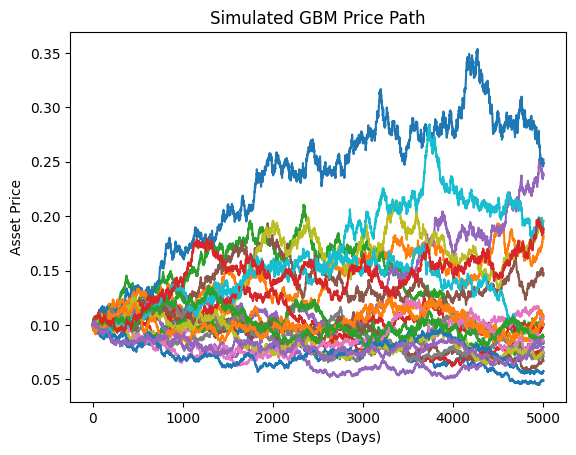

In [218]:
from defipy import BrownianModel
import matplotlib.pyplot as plt

# Step 1: Define parameter settings
n_steps = 5000
start_price = 0.1
mu = 0.3; sigma = 0.5
n_paths = 25

# Step 2: Initialize GBM  with initial price, 
model = BrownianModel(start_price)

# Step 3: Simulate a price path with drift, volatility, time horizon, and steps
p_arr = model.gen_gbms(mu, sigma, n_steps, n_paths)

# Visualize the result
plt.plot(p_arr)
plt.title("Simulated GBM Price Path")
plt.xlabel("Time Steps (Days)")
plt.ylabel("Asset Price")
plt.show()